Dataset Shape: 1000 rows, 16 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     1000 non-null   object 
 1   age                            1000 non-null   int64  
 2   gender                         1000 non-null   object 
 3   study_hours_per_day            1000 non-null   float64
 4   social_media_hours             1000 non-null   float64
 5   netflix_hours                  1000 non-null   float64
 6   part_time_job                  1000 non-null   object 
 7   attendance_percentage          1000 non-null   float64
 8   sleep_hours                    1000 non-null   float64
 9   diet_quality                   1000 non-null   object 
 10  exercise_frequency             1000 non-null   int64  
 11  parental_education_level       909 non-null    object 
 12  internet_qu

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


parental_education_level    91
dtype: int64
Numerical Variables (9): ['age', 'study_hours_per_day', 'social_media_hours', 'netflix_hours', 'attendance_percentage', 'sleep_hours', 'exercise_frequency', 'mental_health_rating', 'exam_score']
Categorical Variables (6): ['gender', 'part_time_job', 'diet_quality', 'parental_education_level', 'internet_quality', 'extracurricular_participation']


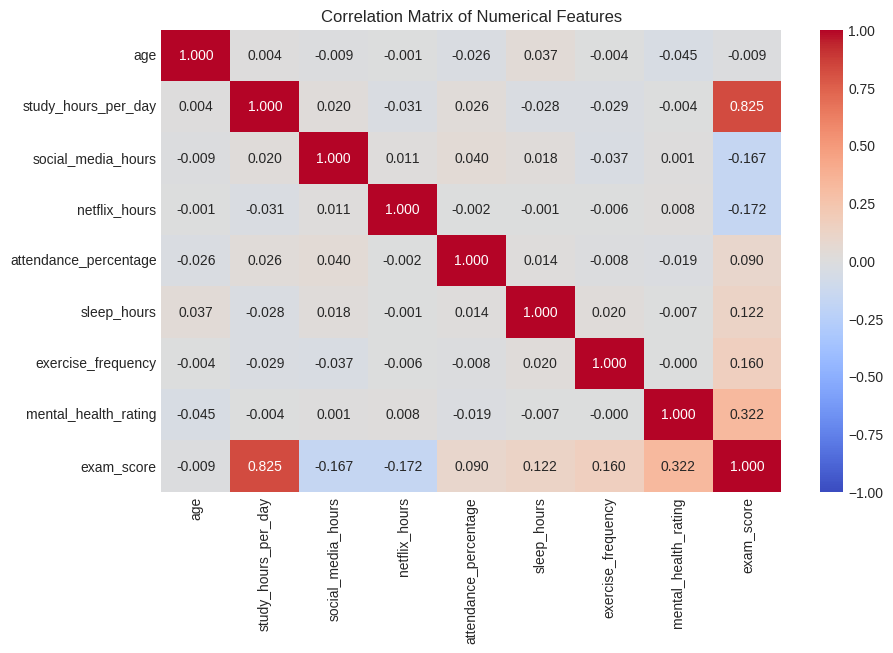

exam_score               1.000000
study_hours_per_day      0.825419
mental_health_rating     0.321523
exercise_frequency       0.160107
sleep_hours              0.121683
attendance_percentage    0.089836
age                     -0.008907
social_media_hours      -0.166733
netflix_hours           -0.171779
Name: exam_score, dtype: float64


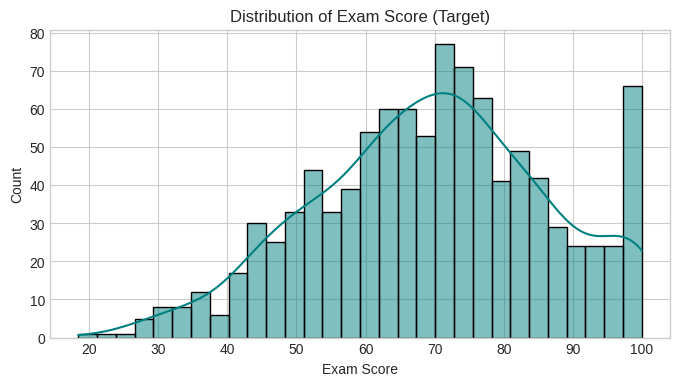

Train MAE : 4.2142 | Test MAE : 4.1923
Train RMSE: 5.3447 | Test RMSE: 5.1510
Train R²  : 0.9021 | Test R²  : 0.8965
Train Accuracy: 0.9587 | Test Accuracy: 0.9550
Test Precision: 0.9714
Test Recall   : 0.9770
Test F1-Score : 0.9742


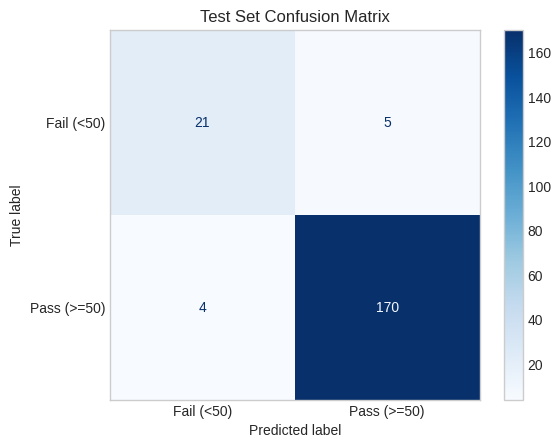

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', None)

df = pd.read_csv('Day18_19_student_habits_performance.csv')

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns\n")
print(df.info())
display(df.head())

print(df.isnull().sum()[df.isnull().sum() > 0])

num_vars = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_vars = df.select_dtypes(include=['object']).columns.tolist()
cat_vars.remove('student_id')

print(f"Numerical Variables ({len(num_vars)}): {num_vars}")
print(f"Categorical Variables ({len(cat_vars)}): {cat_vars}")

plt.figure(figsize=(10, 6))
corr = df[num_vars].corr()
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Matrix of Numerical Features")
plt.show()

print(corr['exam_score'].sort_values(ascending=False))

plt.figure(figsize=(8, 4))
sns.histplot(df['exam_score'], kde=True, color='teal', bins=30)
plt.title("Distribution of Exam Score (Target)")
plt.xlabel("Exam Score")
plt.show()

X = df.drop(columns=['student_id', 'exam_score'])
y_reg = df['exam_score']
y_clf = (df['exam_score'] >= 50).astype(int)

feature_num = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
feature_cat = X.select_dtypes(include=['object']).columns.tolist()

num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, feature_num),
    ('cat', cat_transformer, feature_cat)
])

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)


reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

reg_pipeline.fit(X_train_r, y_train_r)

y_train_pred_r = reg_pipeline.predict(X_train_r)
y_test_pred_r = reg_pipeline.predict(X_test_r)

mae_train = mean_absolute_error(y_train_r, y_train_pred_r)
mae_test = mean_absolute_error(y_test_r, y_test_pred_r)
rmse_train = np.sqrt(mean_squared_error(y_train_r, y_train_pred_r))
rmse_test = np.sqrt(mean_squared_error(y_test_r, y_test_pred_r))
r2_train = r2_score(y_train_r, y_train_pred_r)
r2_test = r2_score(y_test_r, y_test_pred_r)

print(f"Train MAE : {mae_train:.4f} | Test MAE : {mae_test:.4f}")
print(f"Train RMSE: {rmse_train:.4f} | Test RMSE: {rmse_test:.4f}")
print(f"Train R²  : {r2_train:.4f} | Test R²  : {r2_test:.4f}")


clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42))
])

clf_pipeline.fit(X_train_c, y_train_c)

y_train_pred_c = clf_pipeline.predict(X_train_c)
y_test_pred_c = clf_pipeline.predict(X_test_c)

acc_train = accuracy_score(y_train_c, y_train_pred_c)
acc_test = accuracy_score(y_test_c, y_test_pred_c)
prec_test = precision_score(y_test_c, y_test_pred_c)
rec_test = recall_score(y_test_c, y_test_pred_c)
f1_test = f1_score(y_test_c, y_test_pred_c)
cm = confusion_matrix(y_test_c, y_test_pred_c)

print(f"Train Accuracy: {acc_train:.4f} | Test Accuracy: {acc_test:.4f}")
print(f"Test Precision: {prec_test:.4f}")
print(f"Test Recall   : {rec_test:.4f}")
print(f"Test F1-Score : {f1_test:.4f}")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fail (<50)', 'Pass (>=50)'])
disp.plot(cmap='Blues')
plt.title("Test Set Confusion Matrix")
plt.grid(False)
plt.show()